In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt     # 그래프 그리듯이 이미지를 그림
import skimage.data

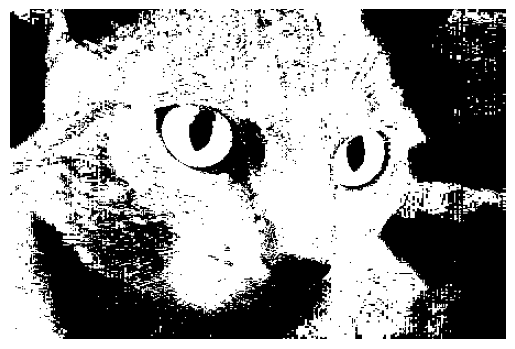

In [18]:
lower_orange_fur_hsv = np.array([12,  50,  50])
upper_orange_fur_hsv = np.array([38, 230, 230])

cat = skimage.data.chelsea()
r = cv2.cvtColor(cat, cv2.COLOR_RGB2HSV) # TODO: 이미지를 HSV 색공간으로 변환

# TODO: 이진 마스크 생성
mask = cv2.inRange(r, lower_orange_fur_hsv, upper_orange_fur_hsv) 
                      
plt.imshow(mask, cmap="gray")                        # TODO: 이미지 출력
plt.axis("off");

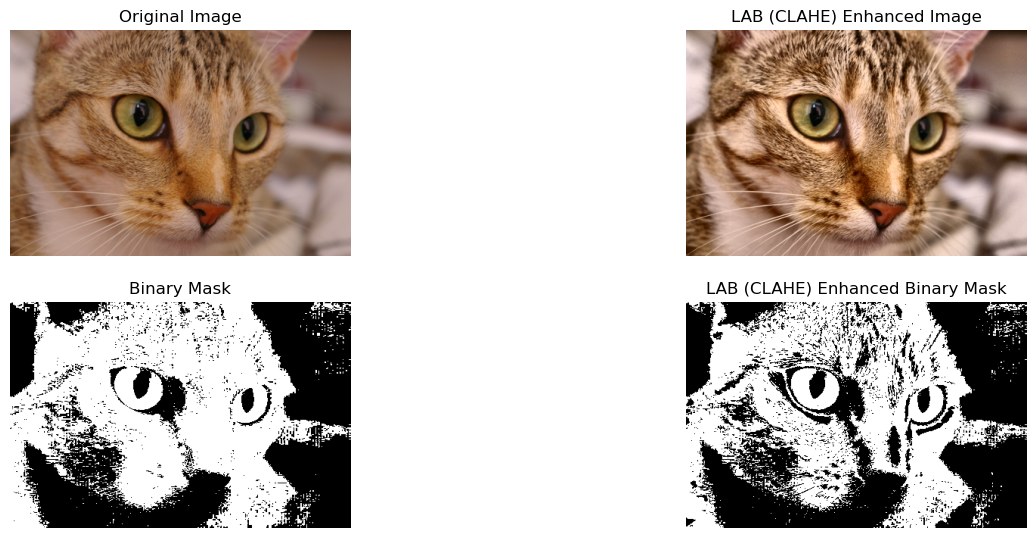

In [ ]:
# TODO: 이미지를 LAB 색공간으로 변환
cat_lab = cv2.cvtColor(cat, cv2.COLOR_RGB2LAB)

# lower_orange_lab = np.array([ 70, 130,  70])
# upper_orange_lab = np.array([180, 230, 185])
# mask_lab = cv2.inRange(lab, lower_orange_lab, upper_orange_lab)
# cat_lab = cv2.bitwise_and(cat, cat, mask=mask_lab)

# # TODO: 각 채널을 분리
# l, a, b = ...
l, a, b = cv2.split(cat_lab)  

# CLAHE 생성 (clip 제한 2.0, 타일 크기 8x8)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)) # tileGridSize : 커널(?)

# L (Lightness) 강화
enhanced_l = clahe.apply(l)
enhanced_lab = cv2.merge((enhanced_l, a, b))

# # TODO: LAB에서 HSV 색공간으로 바로 변환을 할 수 없으므로, RGB로 변환 후 HSV로 변환
enhanced_rgb = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
enhanced_hsv = cv2.cvtColor(enhanced_rgb, cv2.COLOR_RGB2HSV)

# # TODO: 강화된 이미지를 사용하여 이진 마스크 생성 (강화 전과 동일한 lower/upper HSV range 사용)
lower_orange_fur_hsv = np.array([12,  50,  50]) # s, v 는 넓게 설장
upper_orange_fur_hsv = np.array([38, 230, 230])
enhanced_cat_mask = cv2.inRange(enhanced_hsv, lower_orange_fur_hsv, upper_orange_fur_hsv)
# mask = cv2.bitwise_or(mask1, mask2)

plt.figure(figsize=(16,10))
plt.subplot(3,2,1), plt.imshow(cat), plt.title("Original Image")
plt.subplot(3,2,2), plt.imshow(enhanced_rgb), plt.title("LAB (CLAHE) Enhanced Image")
plt.subplot(3,2,3), plt.imshow(mask, cmap="gray"), plt.title("Binary Mask")
plt.subplot(3,2,4), plt.imshow(enhanced_cat_mask, cmap="gray"), plt.title("LAB (CLAHE) Enhanced Binary Mask")

#plt.subplot(3,2,5), plt.imshow(mask_lab, cmap="gray"), plt.title("enhanced_hsv")
#plt.subplot(3,2,6), plt.imshow(cat_lab), plt.title("lab")

for ax in plt.gcf().axes:
    ax.axis("off")

### Basketball

NameError: name 'mask_hsv' is not defined

### 최소 외접원 (Minimum Enclosing Circle):

“외곽선의 모든 점들을 포함하는 가장 작은 원”

(x, y), radius = cv2.minEnclosingCircle(largest_contour)



### Moments를 통해 무게중심 (Centroid) 산출
M = cv2.moments(largest_contour)
'''
m00 : 면적
'''

if M["m00"] != 0:
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
else:
    cX, cY = 0, 0

```
(.venv) kimsangkook@kimsangkook-desktop:~/Documents/Vision_LLM$ v4l2-ctl --list-formats-ext -d /dev/video0
ioctl: VIDIOC_ENUM_FMT
        Type: Video Capture

        [0]: 'RG10' (10-bit Bayer RGRG/GBGB)
                Size: Discrete 3280x2464
                        Interval: Discrete 0.048s (21.000 fps)
                Size: Discrete 3280x1848
                        Interval: Discrete 0.036s (28.000 fps)
                Size: Discrete 1920x1080
                        Interval: Discrete 0.033s (30.000 fps)
                Size: Discrete 1640x1232
                        Interval: Discrete 0.033s (30.000 fps)
                Size: Discrete 1280x720
                        Interval: Discrete 0.017s (60.000 fps)
                        ```